In [110]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary 
from torch.utils.data import DataLoader , TensorDataset
import torchvision
import torchvision.transforms as T

from sklearn.model_selection import train_test_split

import copy
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [111]:
### MNIST data

# import dataset
data = np.loadtxt(open('sample_data/mnist_train_small.csv','rb'),delimiter=',')

# extract labels, normalize, reshape
labelsT   = torch.tensor( data[:,0] ).long()
data      = data[:,1:]
dataNorm  = data / np.max(data)
dataNormT = torch.tensor( dataNorm.reshape(dataNorm.shape[0],1,28,28) ).float()

# split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataNormT, labelsT, test_size=.1)

# convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# translate into dataloader objects
batchsize    = 32
numbers_train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
numbers_test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [112]:
### EMNIST data

# Data
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.EMNIST(root='./data', split='letters', train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


In [113]:
# Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 26)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

model = CNN().to(device)


In [114]:
# Training setup
lossfun = nn.CrossEntropyLoss()




In [115]:
def function2trainTheModel(net, optimizer , train_loader, test_loader, numepochs):

    losses = []
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ----- TRAIN -----
        net.train()
        batchAcc = []
        batchLoss = []

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # store loss
            batchLoss.append(loss.item())

            # accuracy
            preds = torch.argmax(yHat, dim=1)
            acc = (preds == y).float().mean().item() * 100
            batchAcc.append(acc)

        # epoch metrics
        trainAcc.append(np.mean(batchAcc))
        losses.append(np.mean(batchLoss))

        # ----- TEST -----
        net.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                y = y.to(device)

                yHat = net(X)
                preds = torch.argmax(yHat, dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        test_accuracy = 100 * correct / total
        testAcc.append(test_accuracy)

 

    return trainAcc, testAcc, losses, net

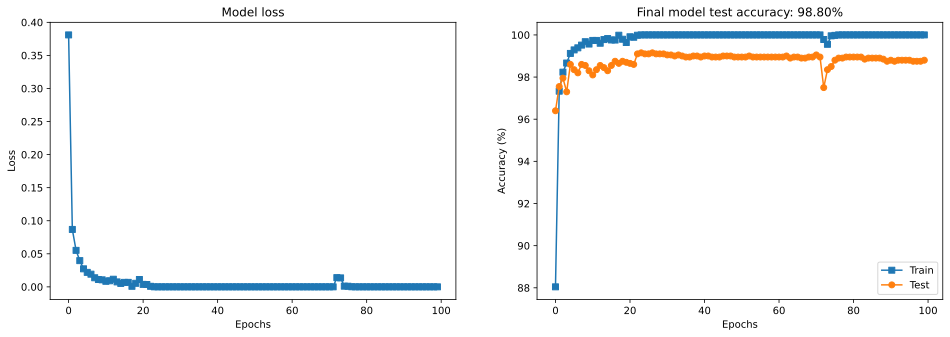

In [116]:
# now re-train the network on the numbers data
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
trainAcc, testAcc, losses, net = function2trainTheModel(
                                                   model,optimizer ,numbers_train_loader,numbers_test_loader,numepochs=100)
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()


In [117]:
# create the target model
model_number = CNN().to(device)


# then replace all the weights in TARGET model from SOURCE model
for target,source in zip(model_number.named_parameters(),model.named_parameters()):
  target[1].data = copy.deepcopy( source[1].data )
  
# check out the network
print(model_number)
print(' ')

# and the final layer
print(model_number.fc)

# replace the final layer to have 10 outputs instead of 26
model_number.fc[3] = nn.Linear(128,10)
model_number = model_number.to(device)

# and check it again
print(' ')
print(model_number)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)
 
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3136, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=26, bias=True)
)
 
CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32,

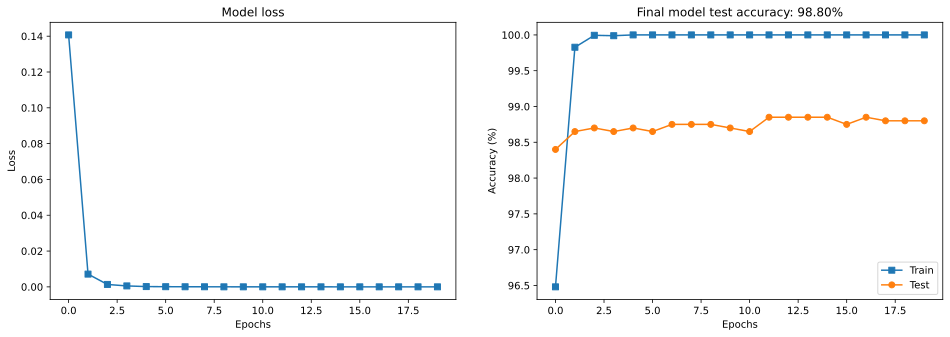

In [118]:
# now re-train the network on the numbers data
optimizer2 = torch.optim.Adam(model_number.parameters(), lr=0.001)
trainAcc, testAcc, losses, net = function2trainTheModel(
                                                   model_number,optimizer2 ,numbers_train_loader,numbers_test_loader,numepochs=20)
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()
